# 03 - Dense SU2 AoA x Mach Modeling

This notebook extends the baseline Cp surrogate study by generating a larger independent-case SU2 dataset over angle of attack and Mach number.

Experiment grid:
- AoA = 0 to 20 degrees at 1-degree increments (21 values)
- Mach = 0.68 to 0.78 at 0.02 increments (6 values)
- Total CFD cases = 126

Why this grid:
1. The AoA range stays consistent with the original Kaggle baseline.
2. The Mach sweep adds genuinely new independent flow conditions.
3. The selected Mach range stays in a relevant transonic regime for RAE2822 without making the study unnecessarily broad in the first extension round.

Goal:
- Generate a larger independent-case dataset.
- Train the same Cp surrogate pipeline on this AoA x Mach dataset.
- Check whether the previous model ranking remains consistent under richer operating conditions.

Extended set:
- AoA = -4 to 24 by 1 degree (29 values)
- Mach = 0.68 to 0.78 by 0.02 (6 values)
- Total CFD cases = 174

## 1. Download AoA x Mach dataset

In [1]:
from cfd_ml.data import load_rae2822_surface_data
from cfd_ml.paths import AOA_MACH_RAE2822_CASE_DIR

aoa_mach_df = load_rae2822_surface_data(AOA_MACH_RAE2822_CASE_DIR)

print("Rows:", len(aoa_mach_df))
print("AoA cases:", aoa_mach_df["AoA"].nunique())
print("Freestream Mach cases:", aoa_mach_df["Freestream_Mach"].nunique())
print("AoA range:", aoa_mach_df["AoA"].min(), "to", aoa_mach_df["AoA"].max())
print(
    "Mach range:",
    aoa_mach_df["Freestream_Mach"].min(),
    "to",
    aoa_mach_df["Freestream_Mach"].max(),
)

aoa_mach_df.head()

Rows: 33408
AoA cases: 29
Freestream Mach cases: 6
AoA range: -4.0 to 24.0
Mach range: 0.68 to 0.78


,PointID,x,y,Density,Momentum_x,Momentum_y,Energy,Nu_Tilde,Pressure,Temperature,...,Laminar_Viscosity,Skin_Friction_Coefficient_x,Skin_Friction_Coefficient_y,Heat_Flux,Y_Plus,Eddy_Viscosity,Freestream_Mach,AoA,sin_AoA,cos_AoA
0,25,0.985397,0.000943,0.499618,0.0,0.0,112354.573391,0.0,44941.83,313.3594,...,0.000019,0.001197,-5.187388e-05,-0.0,1.666482,0.0,0.68,-4.0,-0.069756,0.997564
1,51,0.969573,0.001489,0.499684,0.0,0.0,112374.683740,0.0,44949.87,313.3743,...,0.000019,0.001016,-2.287885e-05,-0.0,1.535447,0.0,0.68,-4.0,-0.069756,0.997564
2,77,0.952680,0.001679,0.500085,0.0,0.0,112467.520983,0.0,44987.01,313.3819,...,0.000019,0.000896,-5.784624e-07,-0.0,1.442139,0.0,0.68,-4.0,-0.069756,0.997564
3,103,0.934996,0.001511,0.499421,0.0,0.0,112317.669773,0.0,44927.07,313.3803,...,0.000019,0.000818,1.725174e-05,-0.0,1.376848,0.0,0.68,-4.0,-0.069756,0.997564
4,129,0.916822,0.000923,0.498258,0.0,0.0,112052.967554,0.0,44821.19,313.3716,...,0.000019,0.000771,3.163624e-05,-0.0,1.336244,0.0,0.68,-4.0,-0.069756,0.997564


## 2. Create feature / target for AoA x Mach model

In [2]:
features = ["x", "y", "sin_AoA", "cos_AoA", "Freestream_Mach"]
target = "Pressure_Coefficient"

X_aoa_mach = aoa_mach_df[features]
y_aoa_mach = aoa_mach_df[target]

print("Feature matrix shape:", X_aoa_mach.shape)
print("Target shape:", y_aoa_mach.shape)
print("Features:", features)
print("Target:", target)

X_aoa_mach.head()


Feature matrix shape: (33408, 5)
Target shape: (33408,)
Features: ['x', 'y', 'sin_AoA', 'cos_AoA', 'Freestream_Mach']
Target: Pressure_Coefficient


,x,y,sin_AoA,cos_AoA,Freestream_Mach
0,0.985397,0.000943,-0.069756,0.997564,0.68
1,0.969573,0.001489,-0.069756,0.997564,0.68
2,0.952680,0.001679,-0.069756,0.997564,0.68
3,0.934996,0.001511,-0.069756,0.997564,0.68
4,0.916822,0.000923,-0.069756,0.997564,0.68


## 3. Leave-One-Case-Out

In [3]:
case_groups = (
    aoa_mach_df["Freestream_Mach"].map(lambda value: f"{value:.2f}")
    + "__"
    + aoa_mach_df["AoA"].map(lambda value: f"{value:g}")
)

print("Total rows:", len(case_groups))
print("Unique independent cases:", case_groups.nunique())
print(case_groups.head())

Total rows: 33408
Unique independent cases: 174
0    0.68__-4
1    0.68__-4
2    0.68__-4
3    0.68__-4
4    0.68__-4
dtype: object


## 5. Leave-One-Case validation

In [4]:
from sklearn.model_selection import LeaveOneGroupOut

logo_case = LeaveOneGroupOut()
case_splits = list(logo_case.split(X_aoa_mach, y_aoa_mach, case_groups))

print("Number of folds:", len(case_splits))

first_train_idx, first_test_idx = case_splits[0]
print("Train rows in first fold:", len(first_train_idx))
print("Test rows in first fold:", len(first_test_idx))
print("Held-out case:", case_groups.iloc[first_test_idx].unique())

Number of folds: 174
Train rows in first fold: 33216
Test rows in first fold: 192
Held-out case: ['0.68__-1']


## 5. Evaluate model Logic to Case-based Grouping

In [5]:
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def evaluate_model_casewise(model, X, y, groups, reference_df):
    splitter = LeaveOneGroupOut()
    fold_scores = []
    fold_predictions = []

    for fold, (train_idx, test_idx) in enumerate(splitter.split(X, y, groups), start=1):
        fold_model = clone(model)
        fold_model.fit(X.iloc[train_idx], y.iloc[train_idx])

        y_true = y.iloc[test_idx]
        y_pred = fold_model.predict(X.iloc[test_idx])

        held_out_groups = groups.iloc[test_idx].unique()
        if len(held_out_groups) != 1:
            raise ValueError(f"Expected one held-out case per fold, got {held_out_groups}")

        held_out_case = held_out_groups[0]

        fold_scores.append({
            "fold": fold,
            "case": held_out_case,
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "R2": r2_score(y_true, y_pred),
        })

        prediction_frame = reference_df.iloc[test_idx][
            ["AoA", "Freestream_Mach", "x", "y"]
        ].copy()
        prediction_frame["y_true"] = y_true.to_numpy()
        prediction_frame["y_pred"] = y_pred
        prediction_frame["case"] = held_out_case
        fold_predictions.append(prediction_frame)

    return pd.DataFrame(fold_scores), pd.concat(fold_predictions, ignore_index=True)


## 6. Run Baseline models on AoA x Mach Dataset

In [6]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

aoa_mach_models = {
    "Mean baseline": DummyRegressor(strategy="mean"),
    "Linear regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Polynomial ridge d2": make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        StandardScaler(),
        Ridge(alpha=1.0),
    ),
    "Random forest": RandomForestRegressor(
        n_estimators=120,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
    "Gradient boosting": GradientBoostingRegressor(
        n_estimators=160,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
    ),
}

aoa_mach_all_scores = []
aoa_mach_all_predictions = {}

for model_name, model in aoa_mach_models.items():
    print(f"Evaluating {model_name}...")
    scores, predictions = evaluate_model_casewise(
        model,
        X_aoa_mach,
        y_aoa_mach,
        case_groups,
        reference_df=aoa_mach_df,
    )
    scores["model"] = model_name
    aoa_mach_all_scores.append(scores)
    aoa_mach_all_predictions[model_name] = predictions

aoa_mach_scores_df = pd.concat(aoa_mach_all_scores, ignore_index=True)
aoa_mach_scores_df.head()


Evaluating Mean baseline...
Evaluating Linear regression...
Evaluating Polynomial ridge d2...
Evaluating Random forest...
Evaluating Gradient boosting...


,fold,case,MAE,RMSE,R2,model
0,1,0.68__-1,0.282919,0.404446,-0.149452,Mean baseline
1,2,0.68__-2,0.327835,0.440659,-0.117706,Mean baseline
2,3,0.68__-3,0.407014,0.516348,-0.055392,Mean baseline
3,4,0.68__-4,0.507405,0.637515,-0.013196,Mean baseline
4,5,0.68__0,0.290417,0.405481,-0.108282,Mean baseline


In [7]:
aoa_mach_summary_df = (
    aoa_mach_scores_df
    .groupby("model")
    .agg(
        MAE_mean=("MAE", "mean"),
        RMSE_mean=("RMSE", "mean"),
        R2_mean=("R2", "mean"),
        RMSE_std=("RMSE", "std"),
    )
    .sort_values("RMSE_mean")
)

aoa_mach_summary_df

,MAE_mean,RMSE_mean,R2_mean,RMSE_std
model,,,,
Random forest,0.023242,0.042079,0.993433,0.033125
Gradient boosting,0.120687,0.161844,0.932617,0.074854
Polynomial ridge d2,0.359748,0.462505,0.442712,0.082452
Linear regression,0.414215,0.538304,0.212640,0.109174
Mean baseline,0.546932,0.652916,-0.020355,0.116745


## 7. Tune Top Models on AoA x Mach dataset

In [19]:
from cfd_ml.tuning import build_cp_tuning_specs, tune_randomized_search_specs

aoa_mach_tuning_specs = build_cp_tuning_specs(random_state=42)
aoa_mach_tuning_specs = {
    name: aoa_mach_tuning_specs[name]
    for name in [
        "Random forest tuned",
        "Gradient boosting tuned",
    ]
}

aoa_mach_tuning_results_df, aoa_mach_tuned_models = tune_randomized_search_specs(
    aoa_mach_tuning_specs,
    X_aoa_mach,
    y_aoa_mach,
    cv=LeaveOneGroupOut(),
    groups=case_groups,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    search_n_jobs=1,
)

aoa_mach_tuning_results_df

Tuning Random forest tuned...


KeyboardInterrupt: 

In [8]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

aoa_mach_models = {
    "Random forest tuned (copied)": RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        max_features=0.8,
        min_samples_leaf=1,
        min_samples_split=2,
        random_state=42,
        n_jobs=-1,
    ),
    "Gradient boosting tuned (copied)": GradientBoostingRegressor(
        n_estimators=220,
        learning_rate=0.1,
        max_depth=4,
        min_samples_leaf=4,
        subsample=0.75,
        random_state=42,
    ),
}


In [11]:
aoa_mach_tuned_scores = []
aoa_mach_tuned_predictions = {}

for model_name, model in aoa_mach_models.items():
    print(f"Evaluating {model_name}...")
    scores, predictions = evaluate_model_casewise(
        model,
        X_aoa_mach,
        y_aoa_mach,
        case_groups,
        reference_df=aoa_mach_df,
    )
    scores["model"] = model_name
    aoa_mach_tuned_scores.append(scores)
    aoa_mach_tuned_predictions[model_name] = predictions

aoa_mach_tuned_scores_df = pd.concat(aoa_mach_tuned_scores, ignore_index=True)

aoa_mach_tuned_summary_df = (
    aoa_mach_tuned_scores_df
    .groupby("model")
    .agg(
        MAE_mean=("MAE", "mean"),
        RMSE_mean=("RMSE", "mean"),
        R2_mean=("R2", "mean"),
        RMSE_std=("RMSE", "std"),
    )
    .sort_values("RMSE_mean")
)

aoa_mach_tuned_summary_df


Evaluating Random forest tuned (copied)...
Evaluating Gradient boosting tuned (copied)...


,MAE_mean,RMSE_mean,R2_mean,RMSE_std
model,,,,
Random forest tuned (copied),0.020184,0.037514,0.994393,0.031551
Gradient boosting tuned (copied),0.051584,0.077258,0.982516,0.040808


In [12]:
baseline_top_df = (
    aoa_mach_summary_df
    .loc[["Random forest", "Gradient boosting"]]
    .reset_index()
)

tuned_top_df = aoa_mach_tuned_summary_df.reset_index()

final_aoa_mach_comparison_df = pd.concat(
    [baseline_top_df, tuned_top_df],
    ignore_index=True,
)

final_aoa_mach_comparison_df["dataset"] = "AoA x Mach (174 cases)"
final_aoa_mach_comparison_df = final_aoa_mach_comparison_df[
    ["dataset", "model", "MAE_mean", "RMSE_mean", "R2_mean", "RMSE_std"]
].sort_values("RMSE_mean")

final_aoa_mach_comparison_df

,dataset,model,MAE_mean,RMSE_mean,R2_mean,RMSE_std
2,AoA x Mach (174 cases),Random forest tuned (copied),0.020184,0.037514,0.994393,0.031551
0,AoA x Mach (174 cases),Random forest,0.023242,0.042079,0.993433,0.033125
3,AoA x Mach (174 cases),Gradient boosting tuned (copied),0.051584,0.077258,0.982516,0.040808
1,AoA x Mach (174 cases),Gradient boosting,0.120687,0.161844,0.932617,0.074854


In [14]:
!pip install seaborn

     |████████████████████████████████| 294 kB 8.2 MB/s eta 0:00:01
You should consider upgrading via the '/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/.venv/bin/python3 -m pip install --upgrade pip' command.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)

/var/folders/hp/bxrrsg6j0_v_gs7_6jrwzhy40000gn/T/ipykernel_90999/831201560.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_summary_df, x="RMSE_mean", y="model", palette="Blues_r")


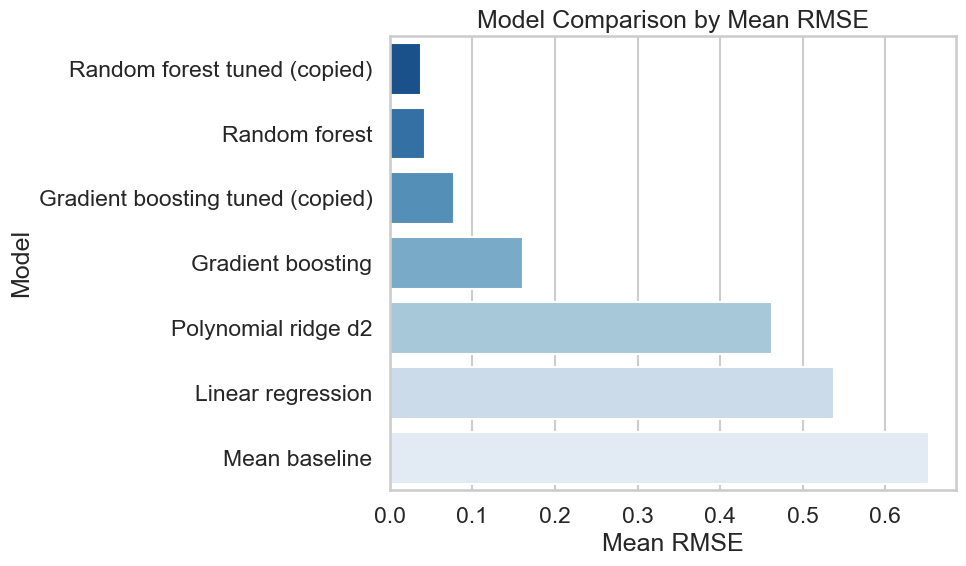

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid", context="talk")

all_scores_df = pd.concat(
    [aoa_mach_scores_df.copy(), aoa_mach_tuned_scores_df.copy()],
    ignore_index=True,
)

all_summary_df = (
    all_scores_df
    .groupby("model", as_index=False)
    .agg(
        MAE_mean=("MAE", "mean"),
        RMSE_mean=("RMSE", "mean"),
        R2_mean=("R2", "mean"),
        RMSE_std=("RMSE", "std"),
    )
    .sort_values("RMSE_mean")
)

plt.figure(figsize=(10, 6))
sns.barplot(data=all_summary_df, x="RMSE_mean", y="model", palette="Blues_r")
plt.title("Model Comparison by Mean RMSE")
plt.xlabel("Mean RMSE")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


/var/folders/hp/bxrrsg6j0_v_gs7_6jrwzhy40000gn/T/ipykernel_90999/914475753.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=compare_df, x="model", y="RMSE_mean", palette="crest")


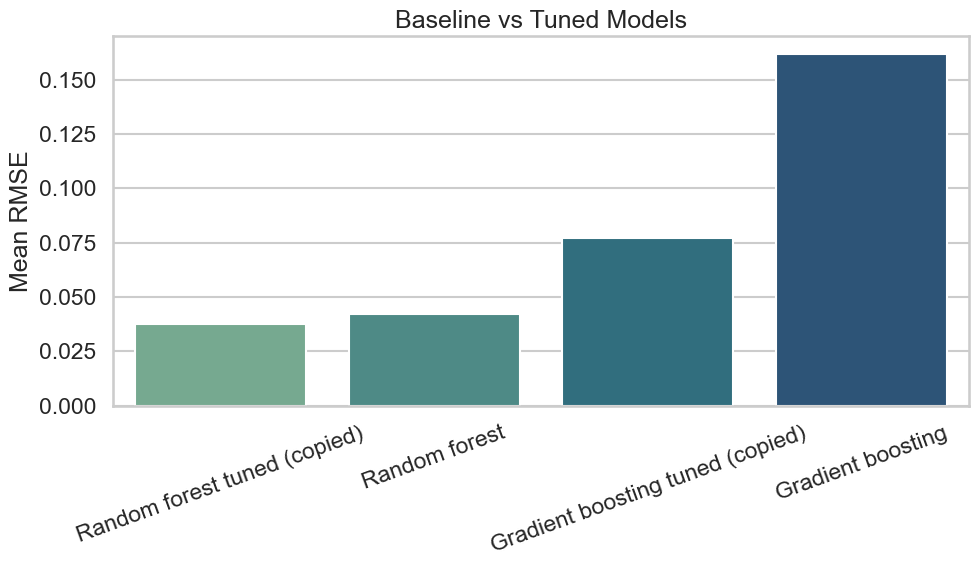

In [33]:
compare_models = [
    "Random forest",
    "Random forest tuned (copied)",
    "Gradient boosting",
    "Gradient boosting tuned (copied)",
]

compare_df = all_summary_df[all_summary_df["model"].isin(compare_models)].copy()

plt.figure(figsize=(10, 6))
sns.barplot(data=compare_df, x="model", y="RMSE_mean", palette="crest")
plt.title("Baseline vs Tuned Models")
plt.xlabel("")
plt.ylabel("Mean RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [42]:
def plot_cases_grid(prediction_df, model_name, case_names):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes = axes.flatten()

    for ax, case_name in zip(axes, case_names):
        case = prediction_df[
            (prediction_df["model"] == model_name) &
            (prediction_df["case"] == case_name)
        ].copy()

        upper = case[case["y"] > 0].sort_values("x")
        lower = case[case["y"] <= 0].sort_values("x")

        ax.plot(upper["x"], upper["y_true"], color="#1f77b4", linewidth=2)
        ax.plot(upper["x"], upper["y_pred"], color="#1f77b4", linestyle="--", linewidth=2)
        ax.plot(lower["x"], lower["y_true"], color="#d62728", linewidth=2)
        ax.plot(lower["x"], lower["y_pred"], color="#d62728", linestyle="--", linewidth=2)

        mach = case["Freestream_Mach"].iloc[0]
        aoa = case["AoA"].iloc[0]

        ax.invert_yaxis()
        ax.set_title(f"Mach={mach:.2f}, AoA={aoa:g}")
        ax.set_xlabel("x/c")
        ax.set_ylabel("Cp")
        ax.grid(True, alpha=0.25)

    handles = [
        plt.Line2D([0], [0], color="#1f77b4", lw=2, label="Upper true"),
        plt.Line2D([0], [0], color="#1f77b4", lw=2, ls="--", label="Upper predicted"),
        plt.Line2D([0], [0], color="#d62728", lw=2, label="Lower true"),
        plt.Line2D([0], [0], color="#d62728", lw=2, ls="--", label="Lower predicted"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=4, frameon=True)
    fig.suptitle(model_name, y=1.02, fontsize=18)
    plt.tight_layout()
    plt.show()


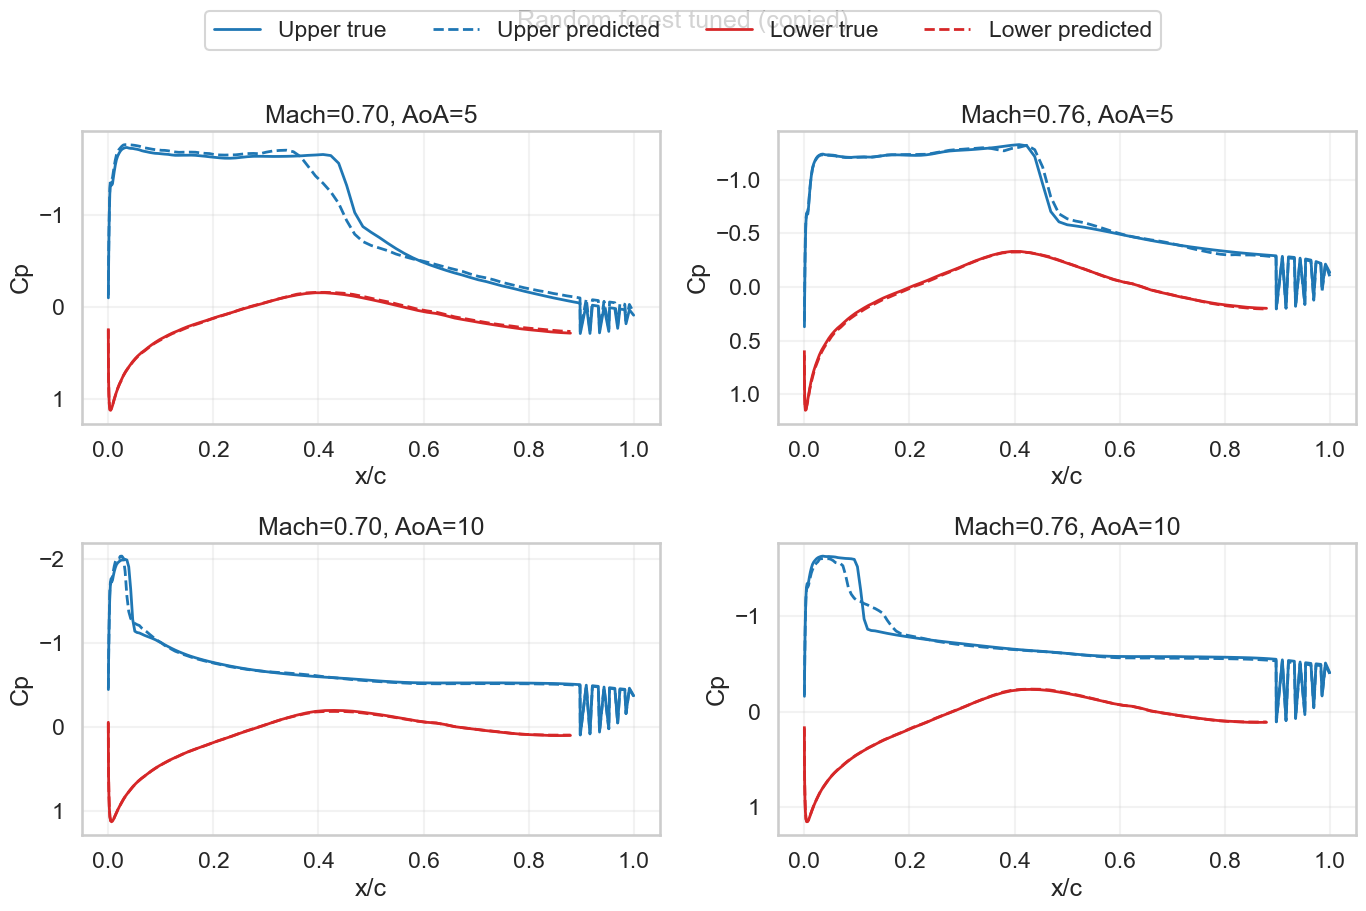

In [43]:
plot_cases_grid(
    prediction_long_df,
    model_name="Random forest tuned (copied)",
    case_names=["0.70__5", "0.76__5", "0.70__10", "0.76__10"],
)

In [45]:
best_model_name = "Random forest tuned (copied)"

best_predictions = prediction_long_df[
    prediction_long_df["model"] == best_model_name
].copy()

best_predictions.head()

,AoA,Freestream_Mach,x,y,y_true,y_pred,case,model,residual
167040,-1.0,0.68,0.985397,0.000943,0.255549,0.258241,0.68__-1,Random forest tuned (copied),0.002693
167041,-1.0,0.68,0.969573,0.001489,0.267519,0.272324,0.68__-1,Random forest tuned (copied),0.004805
167042,-1.0,0.68,0.952680,0.001679,0.277701,0.282410,0.68__-1,Random forest tuned (copied),0.004709
167043,-1.0,0.68,0.934996,0.001511,0.278353,0.282758,0.68__-1,Random forest tuned (copied),0.004405
167044,-1.0,0.68,0.916822,0.000923,0.273617,0.278846,0.68__-1,Random forest tuned (copied),0.005229


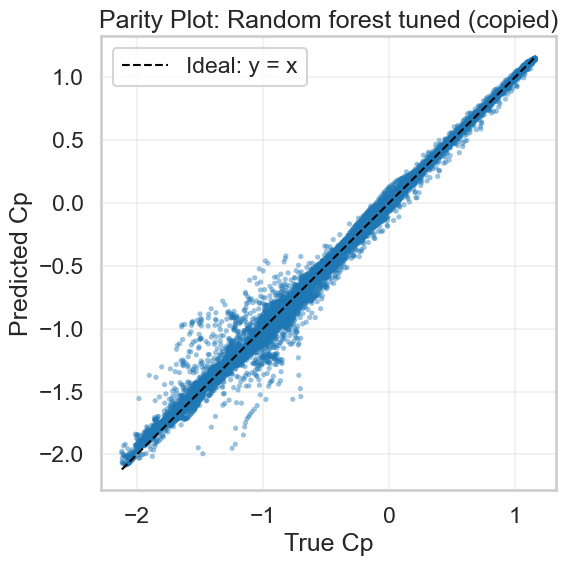

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(6, 6))
plt.scatter(
    best_predictions["y_true"],
    best_predictions["y_pred"],
    s=14,
    alpha=0.45,
    color="#1f77b4",
    edgecolors="none",
)

min_value = min(best_predictions["y_true"].min(), best_predictions["y_pred"].min())
max_value = max(best_predictions["y_true"].max(), best_predictions["y_pred"].max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Ideal: y = x",
)

plt.xlabel("True Cp")
plt.ylabel("Predicted Cp")
plt.title(f"Parity Plot: {best_model_name}")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()
